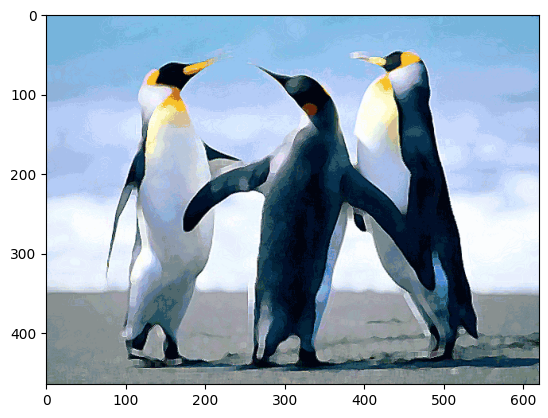

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagemBGR = cv2.imread("penguim.png")
imagem = imagemBGR[:, :, ::-1]
plt.imshow(imagem)

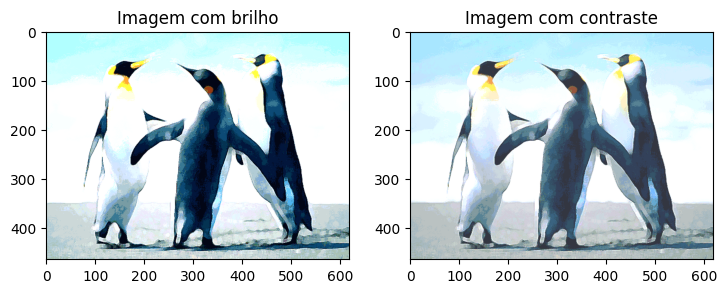

In [13]:
matriz = np.ones(image.shape, dtype="uint8") * 50

#Adicionando brilho
imagem_brilho = cv2.add(imagem, matrix)

#Adicionando contraste
imagem_contraste = cv2.convertScaleAbs(imagem, alpha=1.5, beta=0)

plt.figure(figsize=(18, 5))
plt.subplot(142);plt.imshow(imagem_contraste);plt.title("Imagem com brilho");
plt.subplot(143);plt.imshow(imagem_brilho);plt.title("Imagem com contraste");

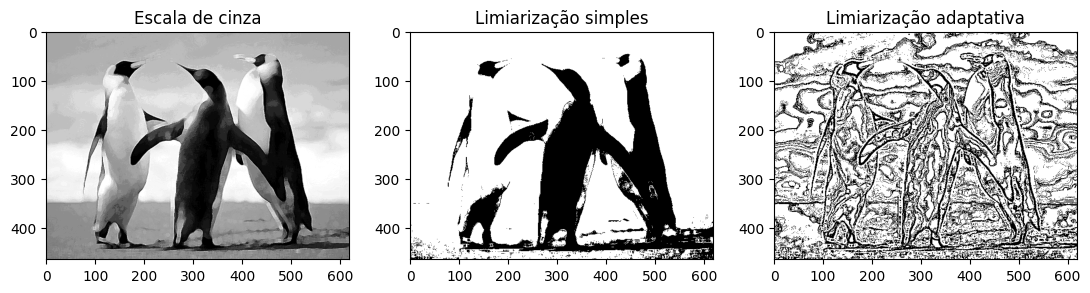

In [24]:
#convertendo para cinza
cinza = cv2.cvtColor(imagem, cv2.COLOR_RGB2GRAY)

#aplicação de threshold binario pixels acima de 127 viram 255, abaixo viram 0 
retval, thresh_bin = cv2.threshold(cinza, 127, 255, cv2.THRESH_BINARY)

#aplicação de threshold adaptativo 
thresh_adapt = cv2.adaptiveThreshold(cinza, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                     cv2.THRESH_BINARY, 11, 2)

plt.figure(figsize=(18, 5))
plt.subplot(141);plt.imshow(cinza, cmap='gray');plt.title("Escala de cinza");
plt.subplot(142);plt.imshow(thresh_bin, cmap='gray');plt.title("Limiarização simples");
plt.subplot(143);plt.imshow(thresh_adapt, cmap='gray');plt.title("Limiarização adaptativa");

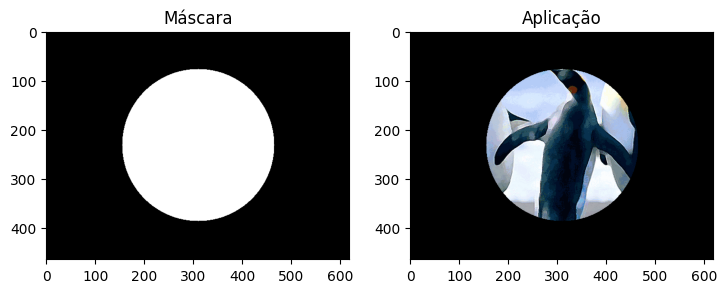

In [30]:
#cria mascara do mesmo tamanho da imagem
mascara = np.zeros(imagem.shape[:2], dtype="uint8")

#desenha um circulo branco
altura, largura= imagem.shape[:2]
centro = (largura // 2, altura // 2)
cv2.circle(mascara, centro, min(altura, largura) // 3, 255, -1)

#so aparece onde ta branco
img_final = cv2.bitwise_and(imagem, imagem, mask=mascara)

#Inverte as cores
mascara_inv = cv2.bitwise_not(mascara)

plt.figure(figsize=(18, 5))
plt.subplot(141);plt.imshow(mascara, cmap='gray');plt.title("Máscara");
plt.subplot(142);plt.imshow(img_final);plt.title("Aplicação");